In [18]:
# Connecting to MongoDB

from pyspark.sql import SparkSession
from pymongo import MongoClient
import pandas as pd
import seaborn as sns

# Creating Spark Session
# spark = SparkSession.builder \
#     .appName("PlaystoreAnalysis") \
#     .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0") \
#     .getOrCreate()
spark = SparkSession.builder \
    .appName("PlaystoreAnalysis") \
    .config("spark.jars.packages", 
            "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0") \
    .config("spark.mongodb.read.connection.uri", 
            "mongodb://127.0.0.1:27017") \
    .config("spark.mongodb.write.connection.uri", 
            "mongodb://127.0.0.1:27017") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()


client = MongoClient("mongodb://localhost:27017/")
db = client.playstore

In [19]:

# Reading the data from MondoDB
df = spark.read.format("mongodb") \
    .option("database", "playstore") \
    .option("collection", "apps") \
    .load()

# Confirming if the data reading succeeded
df.printSchema()
df.show()

root
 |-- _id: string (nullable = true)
 |-- app_development: struct (nullable = true)
 |    |-- released: timestamp (nullable = true)
 |    |-- last_updated: timestamp (nullable = true)
 |-- app_id: string (nullable = true)
 |-- app_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- details: struct (nullable = true)
 |    |-- size_mb: double (nullable = true)
 |    |-- min_android: string (nullable = true)
 |    |-- content_rating: string (nullable = true)
 |-- developer_id: string (nullable = true)
 |-- features: struct (nullable = true)
 |    |-- ads_supported: boolean (nullable = true)
 |    |-- in_app_purchases: boolean (nullable = true)
 |    |-- editors_choice: boolean (nullable = true)
 |-- popularity_metrics: struct (nullable = true)
 |    |-- rating: double (nullable = true)
 |    |-- rating_count: integer (nullable = true)
 |    |-- installs: long (nullable = true)
 |    |-- min_installs: long (nullable = true)
 |    |-- max_installs: long (nullable 

In [20]:
# As processing data with nested columns is resource consuming, flat MongoDB dataframe will be created
from pyspark.sql.functions import col

df_flat = df.select(
    col("app_id"),
    col("app_name"),
    col("category"),
    col("developer_id"),
    col("popularity_metrics.rating").alias("rating"),
    col("popularity_metrics.rating_count").alias("rating_count"),
    col("popularity_metrics.installs").alias("installs"),
    col("popularity_metrics.min_installs").alias("min_installs"),
    col("popularity_metrics.max_installs").alias("max_installs"),
    col("pricing.is_free").alias("is_free"),
    col("pricing.price").alias("price"),
    col("pricing.currency").alias("currency"),
    col("details.size_mb").alias("size_mb"),
    col("details.min_android").alias("min_android"),
    col("details.content_rating").alias("content_rating"),
    col("features.ads_supported").alias("ads_supported"),
    col("features.in_app_purchases").alias("in_app_purchases"),
    col("features.editors_choice").alias("editors_choice"),
    col("app_development.released").alias("released"),
    col("app_development.last_updated").alias("last_updated")
)

print(f"Flat columns for SQL processing: {len(df_flat.columns)}") 
df_flat.printSchema()

spark.catalog.clearCache()

Flat columns for SQL processing: 20
root
 |-- app_id: string (nullable = true)
 |-- app_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- developer_id: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- rating_count: integer (nullable = true)
 |-- installs: long (nullable = true)
 |-- min_installs: long (nullable = true)
 |-- max_installs: long (nullable = true)
 |-- is_free: boolean (nullable = true)
 |-- price: double (nullable = true)
 |-- currency: string (nullable = true)
 |-- size_mb: double (nullable = true)
 |-- min_android: string (nullable = true)
 |-- content_rating: string (nullable = true)
 |-- ads_supported: boolean (nullable = true)
 |-- in_app_purchases: boolean (nullable = true)
 |-- editors_choice: boolean (nullable = true)
 |-- released: timestamp (nullable = true)
 |-- last_updated: timestamp (nullable = true)



In [21]:
# Confirm again, that correct quantity of documents is pulled
print(f"Total records should be 2306246, is {df_flat.count()}")
print(f"Total columns should be 20, is {len(df_flat.columns)}")

Total records should be 2306246, is 2306246
Total columns should be 20, is 20


## Data Analysis and Visualization

### Dependency analysis of apps popularity metrics, price type, categories and editor's choice

The following analysis will compare free and paid apps through their average rating. The results are explained in a written form after the code.

In [22]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, stddev, count, min, max,when, round as spark_round, expr
import pandas as pd
import matplotlib.pyplot as plt


# Create temp view for SQL queries
df_flat.createOrReplaceTempView("apps")


print("="*60)
print("RATING STATISTICS: FREE VS PAID APPS - USING DATAFRAME API")
print("="*60)

# Filter and create price_type column, then aggregate
rating_stats_df = (df_flat
    .filter(col("rating").isNotNull() & (col("rating") > 0))
    .withColumn("price_type", when(col("is_free") == True, "Free").otherwise("Paid"))
    .groupBy("price_type")
    .agg(
        count("*").alias("total_apps_with_ratings"),
        spark_round(avg("rating"), 2).alias("avg_rating"),
        spark_round(stddev("rating"), 2).alias("stddev_rating"),
        spark_round(min("rating"), 2).alias("min_rating"),
        spark_round(max("rating"), 2).alias("max_rating"),
        spark_round(expr("percentile_approx(rating, 0.5)"), 2).alias("median_rating")
    )
)

# ACTION - triggers computation
rating_stats_df.show(truncate=False)


# ============================================================
# ANALYSIS: RATING DISTRIBUTION BY PRICE TYPE
# ============================================================

print("\n" + "="*60)
print("RATING DISTRIBUTION: FREE VS PAID - USING SPARK SQL")
print("="*60)

rating_distribution = spark.sql("""
    SELECT 
        CASE WHEN is_free = true THEN 'Free' ELSE 'Paid' END AS price_type,
        CASE 
            WHEN rating >= 4.5 THEN '4.5 - 5.0 (Excellent)'
            WHEN rating >= 4.0 THEN '4.0 - 4.5 (Good)'
            WHEN rating >= 3.5 THEN '3.5 - 4.0 (Average)'
            WHEN rating >= 3.0 THEN '3.0 - 3.5 (Below Average)'
            WHEN rating >= 2.0 THEN '2.0 - 3.0 (Poor)'
            ELSE 'Below 2.0 (Very Poor)'
        END AS rating_category,
        COUNT(*) AS app_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY is_free), 2) AS percentage
    FROM apps
    WHERE rating IS NOT NULL AND rating > 0
    GROUP BY is_free, rating_category
    ORDER BY is_free DESC, rating_category
""")

rating_distribution.show(20, truncate=False)

# ============================================================
# ANALYSIS: STATISTICAL SIGNIFICANCE
# ============================================================

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE TEST - USING SPARK SQL")
print("="*60)

significance = spark.sql("""
    WITH stats AS (
        SELECT 
            is_free,
            COUNT(*) AS n,
            AVG(rating) AS mean,
            STDDEV(rating) AS stddev,
            VARIANCE(rating) AS variance
        FROM apps
        WHERE rating IS NOT NULL AND rating > 0
        GROUP BY is_free
    )
    SELECT 
        MAX(CASE WHEN is_free= true THEN mean END) AS free_mean,
        MAX(CASE WHEN is_free= false THEN mean END) AS paid_mean,
        MAX(CASE WHEN is_free= true THEN stddev END) AS free_stddev,
        MAX(CASE WHEN is_free= false THEN stddev END) AS paid_stddev,
        MAX(CASE WHEN is_free= true THEN n END) AS free_n,
        MAX(CASE WHEN is_free= false THEN n END) AS paid_n,
        ABS(MAX(CASE WHEN is_free= true THEN mean END) - MAX(CASE WHEN is_free= false THEN mean END)) AS mean_difference
    FROM stats
""").collect()[0]

print(f"Free apps average rating: {significance['free_mean']:.2f}")
print(f"Paid apps average rating: {significance['paid_mean']:.2f}")
print(f"Difference: {significance['mean_difference']:.2f}")

# Calculate effect size (Cohen's d approximation)
pooled_std = ((significance['free_stddev']**2 + significance['paid_stddev']**2) / 2) ** 0.5
effect_size = significance['mean_difference'] / pooled_std

print(f"\nEffect size (Cohen's d): {effect_size:.3f}")
if abs(effect_size) < 0.2:
    print("Interpretation: Negligible effect")
elif abs(effect_size) < 0.5:
    print("Interpretation: Small effect")
elif abs(effect_size) < 0.8:
    print("Interpretation: Medium effect")
else:
    print("Interpretation: Large effect")

# ============================================================
# ANALYSIS: TOP RATED APPS BY PRICE TYPE
# ============================================================

print("\n" + "="*60)
print("TOP 5 HIGHEST RATED FREE APPS - USING SPARK SQL")
print("="*60)

top_free = spark.sql("""
    SELECT 
        app_name,
        category,
        ROUND(rating, 2) AS rating,
        rating_count AS review_count
    FROM apps
    WHERE is_free= true 
        AND rating IS NOT NULL 
        AND rating > 0
    ORDER BY rating DESC
    LIMIT 5
""")
top_free.show(truncate=False)

print("\n" + "="*60)
print("TOP 5 HIGHEST RATED PAID APPS - USING SPARK SQL")
print("="*60)

top_paid = spark.sql("""
    SELECT 
        app_name,
        category,
        ROUND(rating, 2) AS rating,
        rating_count AS review_count,
        CONCAT(price, currency) AS price
    FROM apps
    WHERE is_free= false 
        AND rating IS NOT NULL 
        AND rating > 0
    ORDER BY rating DESC
    LIMIT 5
""")
top_paid.show(truncate=False)

# ============================================================
# ANALYSIS: IMPACT OF EDITOR'S CHOICE ON RATING AND INSTALLATIONS
# ============================================================

print("="*60)
print("IMPACT OF EDITOR'S CHOICE ON INSTALLATIONS RATING - USING DATAFRAME API")
print("="*60)

# Filter and create price_type column, then aggregate
rating_stats_df = (df_flat
    .filter(col("rating").isNotNull() & (col("rating") > 0))
    # .withColumn("price_type", when(col("is_free") == True, "Free").otherwise("Paid"))
    # .groupBy("price_type")
    .groupBy(col("editors_choice"))
    .agg(
        count("*").alias("total_apps"),
        spark_round(avg("installs"), 2).alias("avg_installs"),
        spark_round(avg("rating"), 2).alias("avg_rating"),
        spark_round(stddev("rating"), 2).alias("stddev_rating"),
        spark_round(min("rating"), 2).alias("min_rating"),
        spark_round(max("rating"), 2).alias("max_rating"),
        spark_round(expr("percentile_approx(rating, 0.5)"), 2).alias("median_rating")
    )
)

# ACTION - triggers computation
rating_stats_df.show(truncate=False)


# ============================================================
# ANALYSIS: SUMMARY AND CONCLUSION
# ============================================================

print("\n" + "="*60)
print("SUMMARY AND CONCLUSIONS")
print("="*60)

summary = spark.sql("""
    SELECT 
        CASE WHEN is_free= true THEN 'Free' ELSE 'Paid' END AS price_type,
        COUNT(*) AS total_apps_with_real_ratings,
        ROUND(AVG(rating), 2) AS avg_rating,
        ROUND(PERCENTILE_APPROX(rating, 0.5), 2) AS median_rating,
        ROUND(STDDEV(rating), 3) AS rating_stddev,
        COUNT(CASE WHEN rating >= 4.0 THEN 1 END) AS high_rated_apps,
        ROUND(COUNT(CASE WHEN rating >= 4.0 THEN 1 END) * 100.0 / COUNT(*), 1) AS pct_high_rated
    FROM apps
    WHERE rating IS NOT NULL AND rating > 0
    GROUP BY is_free
""")

summary.show(truncate=False)

# Statistical conclusion
results = summary.collect()
free_avg = [row['avg_rating'] for row in results if row['price_type'] == 'Free'][0]
paid_avg = [row['avg_rating'] for row in results if row['price_type'] == 'Paid'][0]

print(f"\nKEY FINDINGS:")
print(f"• Free apps average rating: {free_avg:.2f}")
print(f"• Paid apps average rating: {paid_avg:.2f}")
print(f"• Difference: {abs(free_avg - paid_avg):.2f} points")
print(f"• Effect size (Cohen's d): {effect_size:.3f}")

if effect_size < 0.2:
    print("\n• CONCLUSION: NO meaningful dependency between rating and price type")
    print("  The rating difference is negligible - less than 0.2 standard deviations")
elif effect_size < 0.5:
    print("\n• CONCLUSION: Weak dependency - Paid apps tend to have slightly higher ratings")
elif effect_size < 0.8:
    print("\n• CONCLUSION: Moderate dependency - Paid apps have noticeably higher ratings")
else:
    print("\n• CONCLUSION: Strong dependency - Paid apps have substantially higher ratings")



RATING STATISTICS: FREE VS PAID APPS - USING DATAFRAME API
+----------+-----------------------+----------+-------------+----------+----------+-------------+
|price_type|total_apps_with_ratings|avg_rating|stddev_rating|min_rating|max_rating|median_rating|
+----------+-----------------------+----------+-------------+----------+----------+-------------+
|Paid      |25383                  |4.15      |0.62         |1.0       |5.0       |4.3          |
|Free      |1202394                |4.1       |0.69         |1.0       |5.0       |4.2          |
+----------+-----------------------+----------+-------------+----------+----------+-------------+


RATING DISTRIBUTION: FREE VS PAID - USING SPARK SQL
+----------+-------------------------+---------+----------+
|price_type|rating_category          |app_count|percentage|
+----------+-------------------------+---------+----------+
|Free      |2.0 - 3.0 (Poor)         |71698    |5.96      |
|Free      |3.0 - 3.5 (Below Average)|103777   |8.63      |

The results show that the paid apps have a slightly higher average rating 4.15 compared to the free apps 4.10. The median rating follows the same pattern. 

Most of the apps, whether it is free or paid, fall into the category of Good or Excellent. 

We performed a statistical analysis to determine whether the difference between free and paid apps is meaningful. The effect size is 0.073 which is negligible. This means that statistically there is no meaningful relationship between the price and ratings.

We took a closer look at the Top 5 highest rated apps and noticed that both free and paid apps have received high scores. Due to the amount of ratings that have resulted in the high score, the reliability is not so good. High ratings do not necessarily indicate the popularity.

We also investigated whether the apps that were selected as Editor's choice are more installed or high rated. The numbers showcase a significant difference in the amount of installs. Editor's choice apps have also a higher rating.

Our final conclusion is that being a Editor's choice app has a bigger impact on the success of the compared to whether the app is paid or free.

### Performance test between DataFrame API vs Spark SQL, with and without cache


This part of the project shows a comparison of the DataFrame API and Spark SQL. To get a fair comparison, we executed the same aggregation query.

The most important finding is that optimizing data access through caching is more critical than the choice between DataFrame API and Spark SQL.

Spark SQL is slightly faster but the massive improvement is gained from caching.


In [23]:
from pyspark.sql.functions import col, avg, stddev, count, min, max, when, round as spark_round, expr
import time

# Empty cache
spark.catalog.clearCache()


# ============================================================
# DataFrame API execution without cache
# ============================================================


# start the timing for performance calculations
start_df_false = time.time()

# Same filtering, aggregation, and metrics as SQL version
df_result_no_cache = (df_flat
    .filter(col("rating").isNotNull() & (col("rating") > 0))
    .withColumn("price_type", when(col("is_free") == True, "Free").otherwise("Paid"))
    .groupBy("price_type")
    .agg(
        count("*").alias("total_apps_with_ratings"),
        spark_round(avg("rating"), 2).alias("avg_rating"),
        spark_round(stddev("rating"), 2).alias("stddev_rating"),
        spark_round(min("rating"), 2).alias("min_rating"),
        spark_round(max("rating"), 2).alias("max_rating"),
        spark_round(expr("percentile_approx(rating, 0.5)"), 2).alias("median_rating")
    )
)

df_result_no_cache.count()

df_time_false = time.time() - start_df_false
print(f"DataFrame API execution time without cache: {df_time_false:.3f} seconds\n")

# ============================================================
# Spark SQL execution without cache
# ============================================================


start_sql_false = time.time()

# IDENTICAL query to DataFrame API
query = """
    SELECT 
        CASE WHEN is_free = true THEN 'Free' ELSE 'Paid' END AS price_type,
        COUNT(*) AS total_apps_with_ratings,
        ROUND(AVG(rating), 2) AS avg_rating,
        ROUND(STDDEV(rating), 2) AS stddev_rating,
        ROUND(MIN(rating), 2) AS min_rating,
        ROUND(MAX(rating), 2) AS max_rating,
        ROUND(PERCENTILE_APPROX(rating, 0.5), 2) AS median_rating
    FROM apps
    WHERE rating IS NOT NULL AND rating > 0
    GROUP BY is_free
"""

sql_result_no_cache = spark.sql(query)
sql_result_no_cache.count()

sql_time_false = time.time() - start_sql_false
print(f"Spark SQL execution time without cache: {sql_time_false:.3f} seconds\n")


# Add cache
df_flat.cache()
df_flat.count()

# ============================================================
# DataFrame API execution with cache
# ============================================================


# start the timing for performance calculations
start_df_true = time.time()

# Same filtering, aggregation, and metrics as SQL version
df_result_cache = (df_flat
    .filter(col("rating").isNotNull() & (col("rating") > 0))
    .withColumn("price_type", when(col("is_free") == True, "Free").otherwise("Paid"))
    .groupBy("price_type")
    .agg(
        count("*").alias("total_apps_with_ratings"),
        spark_round(avg("rating"), 2).alias("avg_rating"),
        spark_round(stddev("rating"), 2).alias("stddev_rating"),
        spark_round(min("rating"), 2).alias("min_rating"),
        spark_round(max("rating"), 2).alias("max_rating"),
        spark_round(expr("percentile_approx(rating, 0.5)"), 2).alias("median_rating")
    )
)

df_result_cache.count()

df_time_true = time.time() - start_df_true
print(f"DataFrame API execution time with cahce: {df_time_true:.3f} seconds\n")

# ============================================================
# Spark SQL execution with cache
# ============================================================


start_sql_true = time.time()

# IDENTICAL query to DataFrame API
query = """
    SELECT 
        CASE WHEN is_free = true THEN 'Free' ELSE 'Paid' END AS price_type,
        COUNT(*) AS total_apps_with_ratings,
        ROUND(AVG(rating), 2) AS avg_rating,
        ROUND(STDDEV(rating), 2) AS stddev_rating,
        ROUND(MIN(rating), 2) AS min_rating,
        ROUND(MAX(rating), 2) AS max_rating,
        ROUND(PERCENTILE_APPROX(rating, 0.5), 2) AS median_rating
    FROM apps
    WHERE rating IS NOT NULL AND rating > 0
    GROUP BY is_free
"""

sql_result_cache = spark.sql(query)
sql_result_cache.count()

sql_time_true = time.time() - start_sql_true
print(f"Spark SQL execution time with cache: {sql_time_true:.3f} seconds\n")



# ============================================================
# PERFORMANCE COMPARISON SUMMARY
# ============================================================
print("="*60)
print("PERFORMANCE COMPARISON SUMMARY WITHOUT CACHE")
print("="*60)
print(f"DataFrame API: {df_time_false:.3f} seconds")
print(f"Spark SQL:    {sql_time_false:.3f} seconds")
print(f"Difference:   {abs(df_time_false - sql_time_false):.3f} seconds")
if df_time_false < sql_time_false:
    print(f"DataFrame API was {(sql_time_false/df_time_false):.2f}x faster")
else:
    print(f"Spark SQL was {(df_time_false/sql_time_false):.2f}x faster")

print("="*60)
print("PERFORMANCE COMPARISON SUMMARY WITH CACHE")
print("="*60)
print(f"DataFrame API: {df_time_true:.3f} seconds")
print(f"Spark SQL:    {sql_time_true:.3f} seconds")
print(f"Difference:   {abs(df_time_true - sql_time_true):.3f} seconds")
if df_time_true < sql_time_true:
    print(f"DataFrame API was {(sql_time_true/df_time_true):.2f}x faster")
else:
    print(f"Spark SQL was {(df_time_true/sql_time_true):.2f}x faster")
print(f"DataFrame API was {(df_time_false/df_time_true):.2f}x faster with cache")
print(f"Spark SQL was {(sql_time_false/sql_time_true):.2f}x faster with cache")


DataFrame API execution time without cache: 10.276 seconds

Spark SQL execution time without cache: 10.889 seconds

DataFrame API execution time with cahce: 0.327 seconds

Spark SQL execution time with cache: 0.254 seconds

PERFORMANCE COMPARISON SUMMARY WITHOUT CACHE
DataFrame API: 10.276 seconds
Spark SQL:    10.889 seconds
Difference:   0.613 seconds
DataFrame API was 1.06x faster
PERFORMANCE COMPARISON SUMMARY WITH CACHE
DataFrame API: 0.327 seconds
Spark SQL:    0.254 seconds
Difference:   0.073 seconds
Spark SQL was 1.29x faster
DataFrame API was 31.42x faster with cache
Spark SQL was 42.82x faster with cache


### MongoDB Aggregation Framework for app price vs. rating comparison 

In [24]:
pipeline = [
    { "$match": { "popularity_metrics.rating": { "$gt": 0 } } },

    { "$addFields": {
        "price_type": {
            "$cond": [ "$pricing.is_free", "Free", "Paid" ]
        }
    }},

    { "$group": {
        "_id": "$price_type",
        "total_apps_with_ratings": { "$sum": 1 },
        "avg_rating": { "$avg": "$popularity_metrics.rating" },
        "stddev_rating": { "$stdDevPop": "$popularity_metrics.rating" },
        "min_rating": { "$min": "$popularity_metrics.rating" },
        "max_rating": { "$max": "$popularity_metrics.rating" },
        "median_rating": {
            "$percentile": {
                "input": "$popularity_metrics.rating",
                "p": [0.5],
                "method": "approximate"
            }
        }
    }}
]

result = list(db.apps.aggregate(pipeline))
df_mongo = pd.DataFrame(result)


df_mongo = df_mongo.rename(columns={"_id": "price_type"})


df_mongo["median_rating"] = df_mongo["median_rating"].apply(lambda x: x[0] if isinstance(x, list) else x)

print("="*60)
print("RATING STATISTICS: FREE VS PAID APPS - USING MONGODB SYNTAX")
print("="*60)


df_mongo


RATING STATISTICS: FREE VS PAID APPS - USING MONGODB SYNTAX


,price_type,total_apps_with_ratings,avg_rating,stddev_rating,min_rating,max_rating,median_rating
0,Free,1202394,4.100197,0.690069,1.0,5.0,4.2
1,Paid,25383,4.148142,0.622219,1.0,5.0,4.3


In [25]:
# Run performance test for pipeline
print("Run again the paid vs. free application's aggregation calculations with Mongo syntax")
start_mongo = time.time()
list(db.apps.aggregate(pipeline))


mongo_time = time.time() - start_mongo
print(f"\nMongo pipeline execution time without cache and withouth indexing: {mongo_time:.3f} seconds\n")

# Add indexing:
db.apps.create_index([("pricing.is_free", 1)])
db.apps.create_index([("popularity_metrics.rating", -1)])

start_mongo_indexed = time.time()
list(db.apps.aggregate(pipeline))
mongo_time_indexed = time.time() - start_mongo_indexed

print(f"Mongo pipeline execution time WITH index: {mongo_time_indexed:.3f} seconds")

Run again the paid vs. free application's aggregation calculations with Mongo syntax

Mongo pipeline execution time without cache and withouth indexing: 5.897 seconds

Mongo pipeline execution time WITH index: 5.418 seconds


In [26]:

# ============================================================
# PERFORMANCE COMPARISON SUMMARY
# ============================================================

print("="*60)
print("PERFORMANCE COMPARISON SUMMARY WITHOUT CACHE")
print("="*60)

print(f"\nDataFrame API: {df_time_false:.3f} seconds")
print(f"Spark SQL:    {sql_time_false:.3f} seconds")
print(f"Mongo pipeline without indexing:    {mongo_time:.3f} seconds")
print(f"Mongo pipeline execution time WITH index: {mongo_time_indexed:.3f} seconds")

print(f"\nDifference unindexed - indexed Mongo pipeline:   {abs(mongo_time - mongo_time_indexed):.3f} seconds")
if mongo_time_indexed < mongo_time:
    print(f"Indexed Mongo pipeline was {(mongo_time/mongo_time_indexed):.2f}x faster")
else:
    print(f"Unindexed Mongo pipeline was {(mongo_time_indexed/mongo_time):.2f}x faster")

print(f"\nDifference DataFrame - indexed Mongo pipeline:   {abs(df_time_false - mongo_time_indexed):.3f} seconds")
if df_time_false > mongo_time_indexed:
    print(f"Indexed Mongo pipeline was {(df_time_false/mongo_time_indexed):.2f}x faster")
else:
    print(f"DataFrame API was {(mongo_time_indexed/df_time_false):.2f}x faster")

print(f"\nDifference SQL - indexed Mongo pipeline:   {abs(sql_time_false - mongo_time_indexed):.3f} seconds")
if sql_time_false > mongo_time_indexed:
    print(f"Indexed Mongo pipeline was {(sql_time_false/mongo_time_indexed):.2f}x faster")
else:
    print(f"Spark SQL was {(mongo_time_indexed/sql_time_false):.2f}x faster")

PERFORMANCE COMPARISON SUMMARY WITHOUT CACHE

DataFrame API: 10.276 seconds
Spark SQL:    10.889 seconds
Mongo pipeline without indexing:    5.897 seconds
Mongo pipeline execution time WITH index: 5.418 seconds

Difference unindexed - indexed Mongo pipeline:   0.479 seconds
Indexed Mongo pipeline was 1.09x faster

Difference DataFrame - indexed Mongo pipeline:   4.857 seconds
Indexed Mongo pipeline was 1.90x faster

Difference SQL - indexed Mongo pipeline:   5.471 seconds
Indexed Mongo pipeline was 2.01x faster


MongoDB syntax appears to be faster for this specific query. One of the reasons might be, that apps without ratings are dropped and Mongo syntax works well for this. Especially after indexing the scanning of full dataset can be skipped.

Then again, after caching, Spark became significantly faster as dataset is stored in memory. This way Spark avoids loading the dataset every time there is a query. With this dataset (around 2.3M rows) the data fits into memory, but with even larger set there could be performance problems. In this case the caching was possible.

## Visualizations of main insights

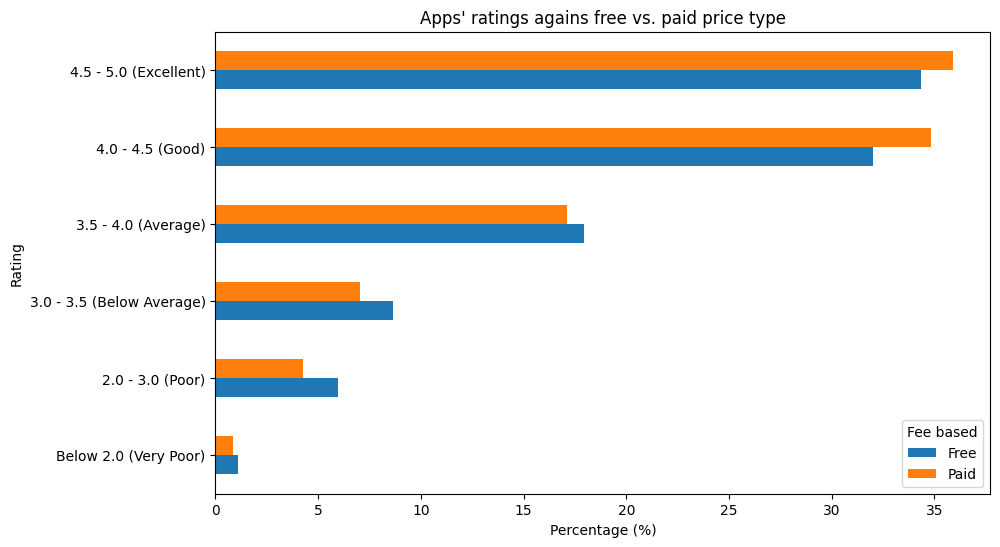

In [27]:
plot_data = rating_distribution.toPandas()

# Percentage to numeric
plot_data['percentage'] = pd.to_numeric(plot_data['percentage'])

x = plot_data.pivot(index='rating_category', columns='price_type', values='percentage')

# Ordering the categories
ordered_cats = [
        'Below 2.0 (Very Poor)', '2.0 - 3.0 (Poor)', 
        '3.0 - 3.5 (Below Average)', '3.5 - 4.0 (Average)', 
        '4.0 - 4.5 (Good)', '4.5 - 5.0 (Excellent)'
    ]

ax = x.reindex(ordered_cats)

# Plotting
ax.plot(kind='barh', figsize=(10, 6))
plt.title("Apps' ratings agains free vs. paid price type")
plt.ylabel("Rating")
plt.xlabel("Percentage (%)")
plt.legend(title="Fee based")
plt.show()

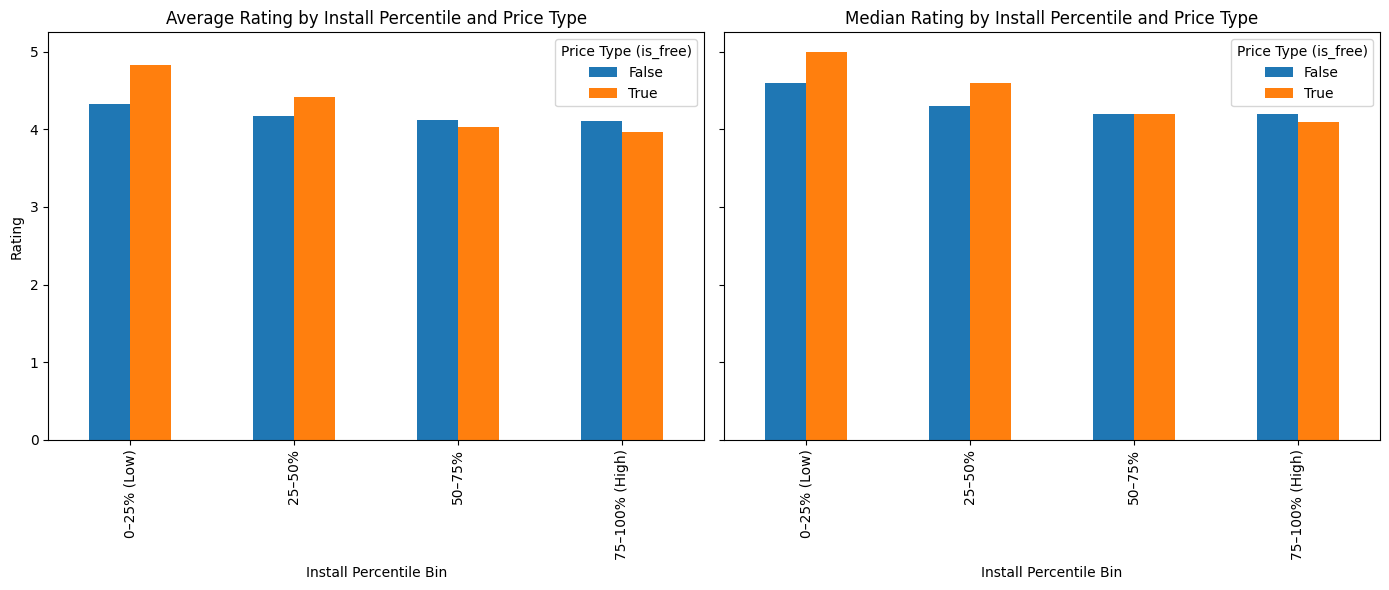

In [28]:
from pyspark.sql import Window
import pyspark.sql.functions as F

# Filter out apps with zero installs
df_nonzero = df_flat.filter(F.col("installs") > 0)

w = Window.orderBy("installs")
df_percentiles = df_nonzero.withColumn(
    "install_percentiles",
    F.percent_rank().over(w)
)

# Bins
df_bins = df_percentiles.withColumn(
    "install_bin",
    F.when(F.col("install_percentiles") < 0.25, "0–25% (Low)")
     .when(F.col("install_percentiles") < 0.50, "25–50%")
     .when(F.col("install_percentiles") < 0.75, "50–75%")
     .otherwise("75–100% (High)")
)

rating_bins = df_bins.groupBy("install_bin", "is_free").agg(F.avg("rating").alias("avg_rating"), F.expr("percentile_approx(rating, 0.5)").alias("median_rating"), F.count("*").alias("count_apps"))


plot_df = rating_bins.toPandas()

# Pivot for average rating
pivot_avg = plot_df.pivot(index="install_bin", columns="is_free", values="avg_rating")
pivot_med = plot_df.pivot(index="install_bin", columns="is_free", values="median_rating")


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

pivot_avg.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Rating by Install Percentile and Price Type")
axes[0].set_xlabel("Install Percentile Bin")
axes[0].set_ylabel("Rating")
axes[0].legend(title="Price Type (is_free)")

pivot_med.plot(kind="bar", ax=axes[1])
axes[1].set_title("Median Rating by Install Percentile and Price Type")
axes[1].set_xlabel("Install Percentile Bin")
axes[1].legend(title="Price Type (is_free)")

plt.tight_layout()
plt.show()



Here bar chart demonstrates, how applications which are free and have below median installs have better ratings. The most downloaded apps on the other hand have slightly better ratings if they are fee based.

## Data analysis of how the amounts of installations vary between free vs. paid applications

In [29]:
from pyspark.sql.functions import col, round as spark_round, avg, count

# Choosing the needed columns and renaming them
install_comparison = df.select(
    col("pricing.is_free").alias("is_free"),
    col("popularity_metrics.installs").alias("installs")
).groupBy("is_free").agg(
    spark_round(avg("installs"), 0).alias("avg_installs"),
    count("*").alias("app_count")
)

print("Comparison between installations (Free vs. Paid):")
install_comparison.show()

Comparison between installations (Free vs. Paid):
+-------+------------+---------+
|is_free|avg_installs|app_count|
+-------+------------+---------+
|   true|    186403.0|  2261591|
|  false|      8889.0|    44655|
+-------+------------+---------+



In [30]:
from pyspark.sql.functions import sum as spark_sum

# Calculating total installations per type
total_installs_df = install_comparison.withColumn(
    "total_volume", col("avg_installs") * col("app_count")
)

# Calculating the sum of all installations for percentage calculation
grand_total = total_installs_df.select(spark_sum("total_volume")).collect()[0][0]

# Calculating percentage
final_stat = total_installs_df.withColumn(
    "install_share_percent", spark_round((col("total_volume") / grand_total) * 100, 2)
).withColumn(
    "count_share_percent", spark_round((col("app_count") / (2261591 + 44655)) * 100, 2)
)

final_stat.show()

+-------+------------+---------+----------------+---------------------+-------------------+
|is_free|avg_installs|app_count|    total_volume|install_share_percent|count_share_percent|
+-------+------------+---------+----------------+---------------------+-------------------+
|   true|    186403.0|  2261591|4.21567347173E11|                99.91|              98.06|
|  false|      8889.0|    44655|    3.96938295E8|                 0.09|               1.94|
+-------+------------+---------+----------------+---------------------+-------------------+



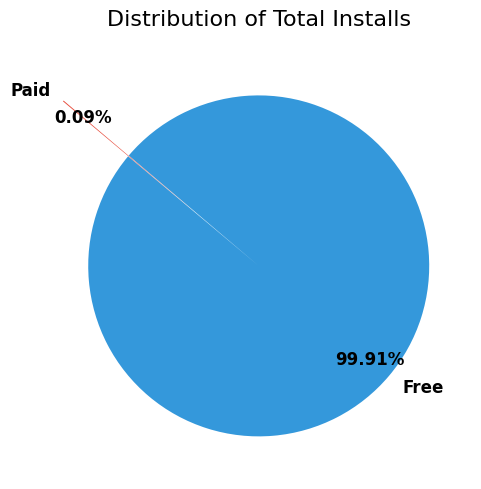

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Data from results
labels = ['Free', 'Paid']
sizes = [99.91, 0.09]
colors = ['#3498db', '#e74c3c']
explode = (0, 0.5)

# Creating pie chart
fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    autopct='%1.2f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

ax.set_title('Distribution of Total Installs', fontsize=16, pad=20)

plt.tight_layout()

#### While paid applications represent only a small fraction of the dataset (1,94%), the sample size of 44,655 is still statistically significant. When installation count is related to application count, they cover only 0,09 % of all installations. This suggests that paid applications have a barrier for extensive popularity.

## Depency analysis of advertisements affecting ratings

In [32]:
df.createOrReplaceTempView("apps_table")

# sql query
sql_results_ads = spark.sql("""
    SELECT 
        features.ads_supported, 
        ROUND(AVG(popularity_metrics.rating), 2) AS avg_rating, 
        COUNT(*) AS app_count
    FROM apps_table
    GROUP BY features.ads_supported
""")

print("Results using Spark SQL:")
sql_results_ads.show()

Results using Spark SQL:
+-------------+----------+---------+
|ads_supported|avg_rating|app_count|
+-------------+----------+---------+
|         true|      4.12|  1148642|
|        false|      4.07|  1157604|
+-------------+----------+---------+



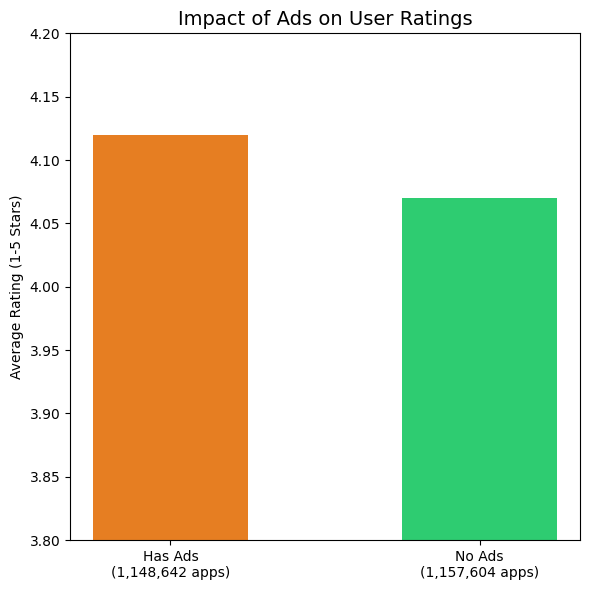

In [33]:
# Data from Spark results
ad_data = pd.DataFrame({
    'Ad Supported': ['Has Ads\n(1,148,642 apps)', 'No Ads\n(1,157,604 apps)'],
    'Avg Rating': [4.12, 4.07]
})

# Creating plot
plt.figure(figsize=(6, 6))
bars = plt.bar(ad_data['Ad Supported'], ad_data['Avg Rating'], color=['#e67e22', '#2ecc71'], width=0.5)

plt.ylim(3.8, 4.2)
plt.title('Impact of Ads on User Ratings', fontsize=14)
plt.ylabel('Average Rating (1-5 Stars)')

plt.tight_layout()
plt.show()

Analysis show a surprising result: Ad-supported applications maintain a higher average rating than those without ads (0.5 difference). This insight may indicate that developers are enabled to provide better maintance and more frequent updates.

### Ratings vs Installs

+----------+-----------------+---------------+----------+
|rating_bin|     avg_installs|median_installs|count_apps|
+----------+-----------------+---------------+----------+
|   1.0–1.9|51715.98990279557|           1000|     13271|
|   2.0–2.9|132816.6763679336|           5000|     72774|
|   3.0–3.9|197715.0960536136|          10000|    325589|
|   4.0–4.9|483196.0613209918|           5000|    716280|
|       5.0|1239.654096111673|            100|     99863|
+----------+-----------------+---------------+----------+



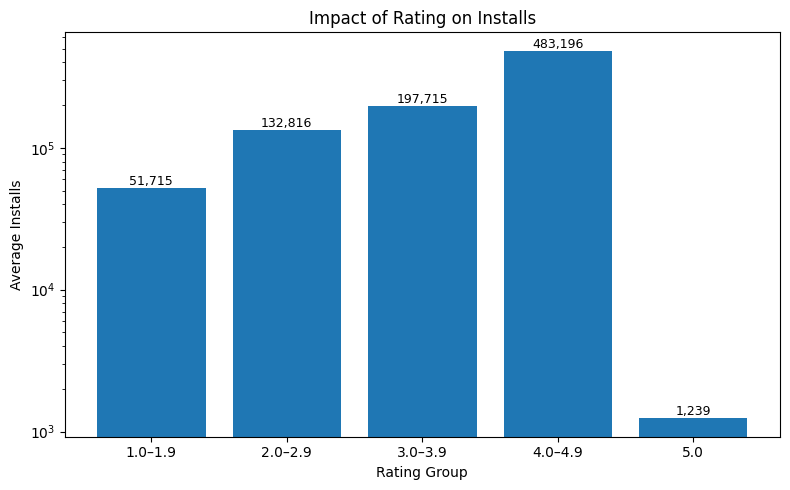

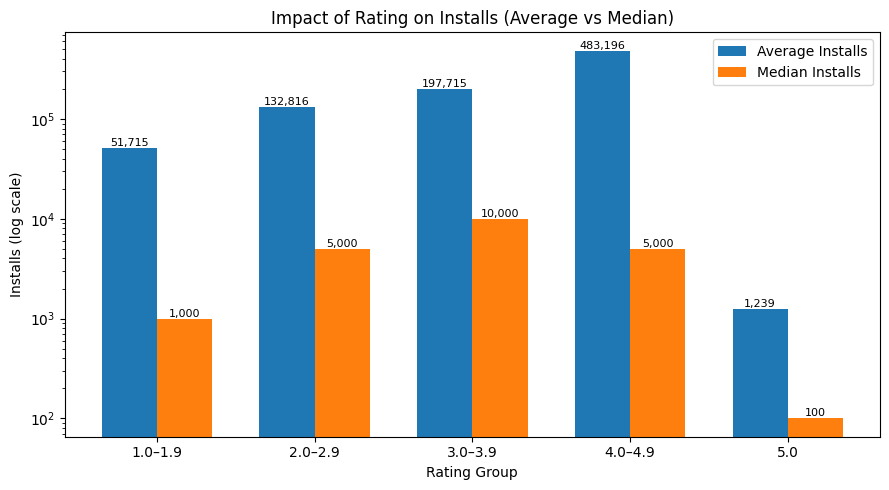

In [34]:
from pyspark.sql.functions import col, avg, count, log10, when, expr
import matplotlib.pyplot as plt

df_analysis = df_flat.select("rating", "installs") \
    .filter(col("rating").isNotNull() & col("installs").isNotNull())

df_analysis = df_analysis.withColumn("log_installs", log10(col("installs")))

df_binned = df_analysis.withColumn(
    "rating_bin",
    when((col("rating") >= 1) & (col("rating") < 2), "1.0–1.9")
    .when((col("rating") >= 2) & (col("rating") < 3), "2.0–2.9")
    .when((col("rating") >= 3) & (col("rating") < 4), "3.0–3.9")
    .when((col("rating") >= 4) & (col("rating") < 5), "4.0–4.9")
    .when(col("rating") == 5, "5.0")
)

df_grouped = df_binned.groupBy("rating_bin") \
    .agg(
        avg("installs").alias("avg_installs"),
        expr("percentile_approx(installs, 0.5)").alias("median_installs"),
        count("*").alias("count_apps")
    ) \
    .orderBy("rating_bin")

df_grouped.show()

pdf_grouped = df_grouped.toPandas()

plt.figure(figsize=(8,5))
bars = plt.bar(pdf_grouped["rating_bin"], pdf_grouped["avg_installs"])

plt.title("Impact of Rating on Installs")
plt.xlabel("Rating Group")
plt.ylabel("Average Installs")
plt.yscale("log")

for bar, value in zip(bars, pdf_grouped["avg_installs"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{int(value):,}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt

labels = pdf_grouped["rating_bin"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9,5))

bars1 = plt.bar(x - width/2, pdf_grouped["avg_installs"], width, label="Average Installs")
bars2 = plt.bar(x + width/2, pdf_grouped["median_installs"], width, label="Median Installs")

plt.xticks(x, labels)
plt.yscale("log")

plt.title("Impact of Rating on Installs (Average vs Median)")
plt.xlabel("Rating Group")
plt.ylabel("Installs (log scale)")
plt.legend()

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=8)

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

The results show a clear positive relationship between app ratings and the number of installs. As ratings increase from 1.0–1.9 to 4.0–4.9, the average number of installs also increases significantly.

However, apps with a perfect 5.0 rating deviate from this trend and have notably fewer installs. This is likely because perfect ratings are more common among newer or less popular apps with fewer users and reviews.

Overall, the analysis suggests that higher ratings are associated with greater popularity, but a perfect rating does not necessarily indicate a high number of installs.